In [22]:
import biogeme.database as db
import geopandas as gpd
import pandas as pd
from biogeme import models
from biogeme.biogeme import BIOGEME
from biogeme.expressions import Beta, Variable
from sklearn.preprocessing import MinMaxScaler

* Costo
* Superficie
* Parques
* Distancia a la frontera
* Baldíos y parques a 5 minutos

In [14]:
df_transactions = pd.read_parquet("./transactions.parquet")

unused_frac = df_transactions["fraccionamiento"].value_counts()
unused_frac = unused_frac[unused_frac < 10].index
df_transactions = df_transactions.loc[
    lambda df: ~df["fraccionamiento"].isin(unused_frac)
]

cat = df_transactions["fraccionamiento"].astype("category")
label_to_frac_map = dict(enumerate(cat.cat.categories))
frac_to_label_map = {v: k for k, v in label_to_frac_map.items()}

price_per_sqm = (
    df_transactions.assign(
        price_per_sqm=lambda df: df["valor_operacion"] / df["mts_superficie"]
    )
    .groupby("fraccionamiento")["price_per_sqm"]
    .median()
)

df_transactions = df_transactions[["fraccionamiento"]].assign(
    fraccionamiento=lambda df: df["fraccionamiento"].map(frac_to_label_map)
)

In [47]:
df_frac_features = (
    gpd.read_parquet("./frac_features.geoparquet")
    .drop(columns=["geometry"])
    .join(price_per_sqm)
)

df_frac_features = (
    df_frac_features.reset_index(names="fraccionamiento")
    .assign(fraccionamiento=lambda df: df["fraccionamiento"].map(frac_to_label_map))
    .dropna(subset=["fraccionamiento"])
    .assign(fraccionamiento=lambda df: df["fraccionamiento"].astype(int))
    .set_index("fraccionamiento")
    .drop(columns=["tree_coverage_frac", "urbanized_area_frac"])
)

for c in df_frac_features.columns:
    df_frac_features[c] = df_frac_features[c].fillna(df_frac_features[c].mean())

In [55]:
scaler = MinMaxScaler()
df_frac_features_scaled = df_frac_features.assign(
    jobs_manufacture=lambda df: df["jobs_manufacture"] / 5_000,
    jobs_infrastructure=lambda df: df["jobs_infrastructure"] / 1_000,
    jobs_specialized=lambda df: df["jobs_specialized"] / 1_000,
    jobs_care=lambda df: df["jobs_care"] / 5_000,
    accessibility=lambda df: df["accessibility"] * 10,
    accessibility_parks=lambda df: df["accessibility_parks"] * 1000,
    travel_time_to_center=lambda df: df["travel_time_to_center"] / 100,
    price_per_sqm=lambda df: df["price_per_sqm"] / 500,
)

In [56]:
feature_dict = {}
for col in df_frac_features_scaled.columns:
    for idx, val in df_frac_features_scaled[col].items():
        feature_dict[f"{col}_{idx}"] = val

for col_name, value in feature_dict.items():
    df_transactions[col_name] = value

df_transactions = df_transactions.copy()  # Defragment DataFrame

In [57]:
database = db.Database("housing_choice_model", df_transactions)

choice = Variable("fraccionamiento")

betas = {
    f"beta_{col}": Beta(f"beta_{col}", 0, None, None, 0)
    for col in df_frac_features.columns
}

V = {}
av = {}
for i in range(len(df_frac_features)):
    var_map = {
        f"var_{col}_{i}": Variable(f"{col}_{i}") for col in df_frac_features.columns
    }
    V[i] = sum(
        betas[f"beta_{col}"] * var_map[f"var_{col}_{i}"]
        for col in df_frac_features.columns
    )
    av[i] = 1

logprob = models.loglogit(V, av, choice)
biogeme_model = BIOGEME(
    database,
    logprob,
    parameters="./params/test_1.yaml",
    generate_yaml=False,
    generate_html=True,
    save_iterations=False,
)
biogeme_model.model_name = "test_1"

results = biogeme_model.estimate()

In [58]:
print(results.short_summary())

Results for model test_1
Nbr of parameters:		8
Sample size:			7106
Excluded data:			0
Final log likelihood:		-19738.4
Akaike Information Criterion:	39492.79
Bayesian Information Criterion:	39547.74



/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_2471/1586264582.py:1: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  params = results.get_estimated_parameters().set_index("Name")["Value"].plot.barh()


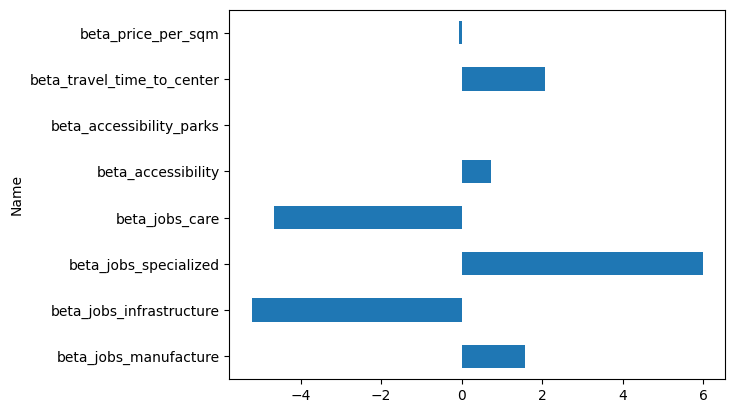

In [59]:
params = results.get_estimated_parameters().set_index("Name")["Value"].plot.barh()

In [53]:
results.get_estimated_parameters()

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_2471/1975322986.py:1: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  results.get_estimated_parameters()


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,beta_jobs_manufacture,15.759848,1.188422,13.261153,0.000000
1,beta_jobs_infrastructure,-52.083784,2.342142,-22.237669,0.000000
2,beta_jobs_specialized,59.846482,3.263062,18.340591,0.000000
3,beta_jobs_care,-46.627731,3.458525,-13.481971,0.000000
4,beta_accessibility,0.726856,0.032673,22.246313,0.000000
5,beta_accessibility_parks,0.055410,0.012480,4.439871,0.000009
6,beta_travel_time_to_center,20.752450,0.703402,29.502967,0.000000
7,beta_price_per_sqm,-0.578880,0.066234,-8.739880,0.000000


In [61]:
print(results.print_general_statistics())

Number of estimated parameters             8
Sample size                                7106
Excluded observations                      0
Init log likelihood                        -22873.33
Final log likelihood                       -19738.4
Likelihood ratio test for the init. model  6269.869
Rho-square for the init. model             0.137
Rho-square-bar for the init. model         0.137
Akaike Information Criterion               39492.79
Bayesian Information Criterion             39547.74
Final gradient norm                        2.0591E-02
Bootstrapping time                         None
